The goal of this project is to explore the two libraries with 'relu' activation function and optimizer(solver) on the Climate model simulation crashes dataset (https://archive.ics.uci.edu/dataset/252/climate+model+simulation+crashes) to predict climate model simulation outcomes (fail or succeed) given scaled values of climate model input parameters.

This dataset contains records of simulation crashes encountered during climate model uncertainty quantification (UQ) ensembles. Column 1: Latin hypercube study ID (study 1 to study 3) Column 2: simulation ID (run 1 to run 180) Columns 3-20: values of 18 climate model parameters scaled in the interval [0, 1] Column 21: simulation outcome (0 = failure, 1 = success)

The MLPClassifier is a library from the sklearn.neural_network module in the Scikit-learn framework, which provides tools for machine learning, including simple neural networks. On the other hand, TensorFlow is a deep learning framework designed for creating more complex and scalable neural network models.

We will explore three solvers, SGD (Stochastic Gradient Descent), Adam (Adaptive Moment Estimation), and L-BFGS (Limited-memory Broyden-Fletcher-Goldfarb-Shanno). These were selected to check how accurately they can perform with stable prediction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, GridSearchCV,  RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.model_selection import cross_val_score

from sklearn.pipeline import Pipeline

import tensorflow as tf


In [2]:
## import dataset
data = pd.read_csv("pop_failures.csv")

# Print column names
print("data column name:")
print(data.columns)

# Print dimensions of the dataset
print("The dimension of the dataset is:")
print(data.shape)

data column name:
Index(['Study', 'Run', 'vconst_corr', 'vconst_2', 'vconst_3', 'vconst_4',
       'vconst_5', 'vconst_7', 'ah_corr', 'ah_bolus', 'slm_corr',
       'efficiency_factor', 'tidal_mix_max', 'vertical_decay_scale',
       'convect_corr', 'bckgrnd_vdc1', 'bckgrnd_vdc_ban', 'bckgrnd_vdc_eq',
       'bckgrnd_vdc_psim', 'Prandtl', 'outcome'],
      dtype='object')
The dimension of the dataset is:
(540, 21)


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 540 entries, 0 to 539
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Study                 540 non-null    int64  
 1   Run                   540 non-null    int64  
 2   vconst_corr           540 non-null    float64
 3   vconst_2              540 non-null    float64
 4   vconst_3              540 non-null    float64
 5   vconst_4              540 non-null    float64
 6   vconst_5              540 non-null    float64
 7   vconst_7              540 non-null    float64
 8   ah_corr               540 non-null    float64
 9   ah_bolus              540 non-null    float64
 10  slm_corr              540 non-null    float64
 11  efficiency_factor     540 non-null    float64
 12  tidal_mix_max         540 non-null    float64
 13  vertical_decay_scale  540 non-null    float64
 14  convect_corr          540 non-null    float64
 15  bckgrnd_vdc1          5

In [4]:
data.describe()

,Study,Run,vconst_corr,vconst_2,vconst_3,vconst_4,vconst_5,vconst_7,ah_corr,ah_bolus,...,efficiency_factor,tidal_mix_max,vertical_decay_scale,convect_corr,bckgrnd_vdc1,bckgrnd_vdc_ban,bckgrnd_vdc_eq,bckgrnd_vdc_psim,Prandtl,outcome
count,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,...,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000
mean,2.000000,90.500000,0.500026,0.500097,0.500027,0.500119,0.500001,0.499913,0.500059,0.500076,...,0.500111,0.499984,0.500032,0.499933,0.499944,0.499946,0.500044,0.500020,0.500021,0.914815
std,0.817254,52.008901,0.288939,0.288922,0.289067,0.288993,0.288827,0.288852,0.289010,0.288909,...,0.288966,0.289127,0.289014,0.288822,0.288949,0.288923,0.288813,0.288936,0.289013,0.279416
min,1.000000,1.000000,0.000414,0.001922,0.001181,0.001972,0.000858,0.000476,0.004590,0.000296,...,0.002015,0.000419,0.001188,0.001312,0.002509,0.000732,0.000891,0.000219,0.000263,0.000000
25%,1.000000,45.750000,0.249650,0.251597,0.251540,0.250158,0.250630,0.251325,0.253048,0.250402,...,0.250758,0.251676,0.249669,0.249988,0.249586,0.249974,0.250412,0.252739,0.249723,1.000000
50%,2.000000,90.500000,0.499998,0.499595,0.500104,0.500456,0.500903,0.499174,0.499070,0.500074,...,0.500393,0.500322,0.500151,0.500625,0.499080,0.499959,0.500384,0.498955,0.499431,1.000000
75%,3.000000,135.250000,0.750042,0.750011,0.749180,0.750348,0.748988,0.748166,0.750109,0.749091,...,0.749447,0.749346,0.749164,0.749569,0.750012,0.747978,0.749256,0.748539,0.749792,1.000000
max,3.000000,180.000000,0.999194,0.998815,0.998263,0.997673,0.998944,0.997142,0.998930,0.998506,...,0.999536,0.999942,0.997718,0.997518,0.999795,0.999155,0.997265,0.999306,0.999655,1.000000


   outcome  count
0        0     46
1        1    494


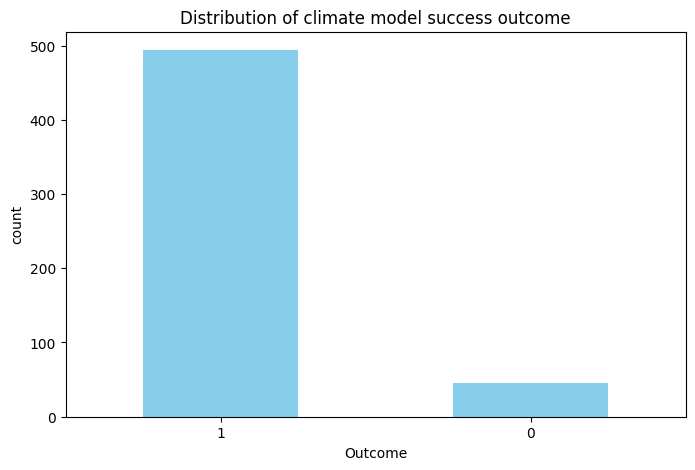

In [5]:
# Group by 'wheatLabel' and count the occurrences of each label to ascertain the state of balancing in the dataset
data_label_count = data.groupby('outcome').size().reset_index(name='count')
print(data_label_count)

data_label_count = data['outcome'].value_counts()
# Plotting
plt.figure(figsize=(8, 5))
data_label_count.plot(kind='bar', color='skyblue')
plt.title("Distribution of climate model success outcome")
plt.xlabel("Outcome")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.savefig("data_label_hist.png")  #save the plot
plt.show()

In [6]:
# Check if there are any duplicate rows in the dataset
duplicates = data.duplicated()
print("Number of duplicate:", duplicates.sum())

Missing_V = data.isna().sum()
print("Sum of missing value: \n", Missing_V)

Number of duplicate: 0
Sum of missing value: 
 Study                   0
Run                     0
vconst_corr             0
vconst_2                0
vconst_3                0
vconst_4                0
vconst_5                0
vconst_7                0
ah_corr                 0
ah_bolus                0
slm_corr                0
efficiency_factor       0
tidal_mix_max           0
vertical_decay_scale    0
convect_corr            0
bckgrnd_vdc1            0
bckgrnd_vdc_ban         0
bckgrnd_vdc_eq          0
bckgrnd_vdc_psim        0
Prandtl                 0
outcome                 0
dtype: int64


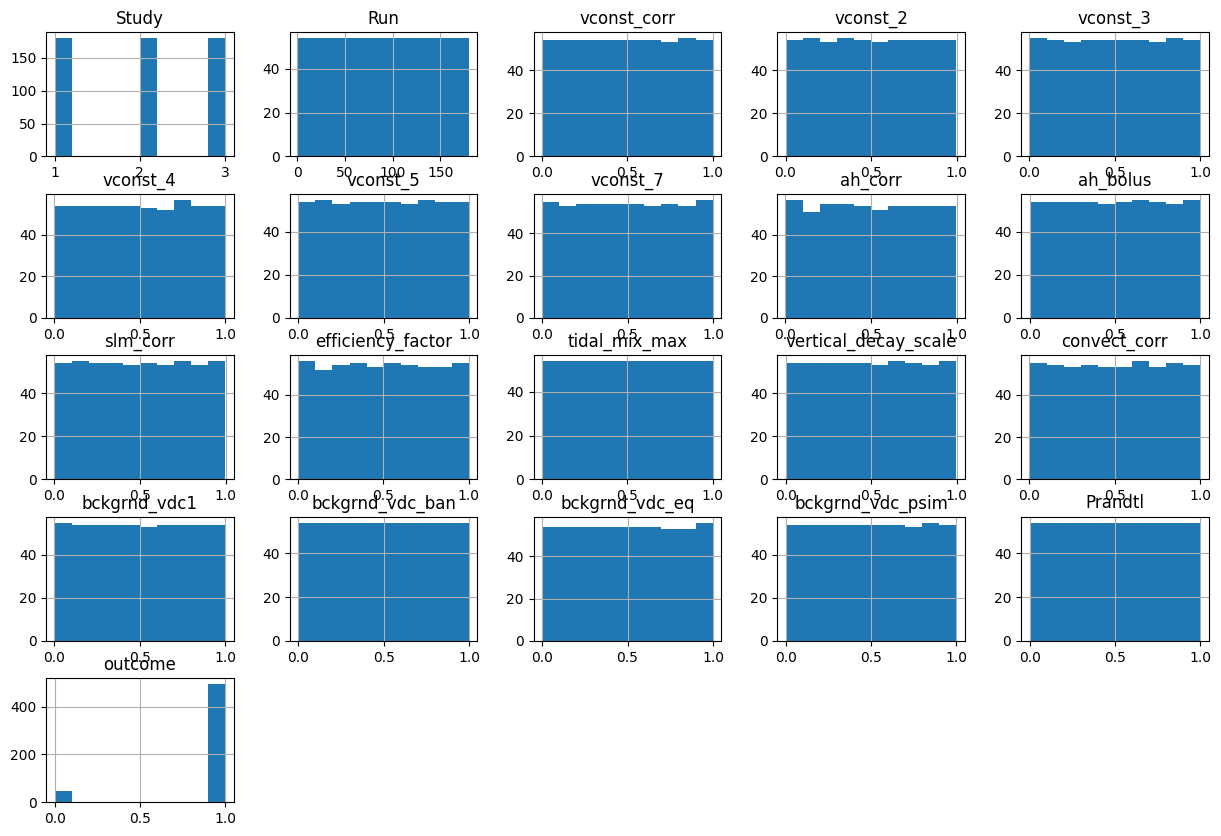

In [7]:
data.hist(figsize=(15,10))
plt.show()



In [8]:
# Separate target and features
X = data.drop(columns=['outcome','Study', 'Run'])
y = data['outcome']


# Label Encode the target variable (Toilet_type)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=123)

In [9]:
# Define and evaluate models
def evaluate_models(models, X_train, y_train, X_test, y_test, cv=10):
    results = {}
    for name, model in models.items():
        print(f"\nTraining and evaluating {name}...")
        model.fit(X_train, y_train)  # Train the model
        y_pred = model.predict(X_test)  # Predict on test data
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=1)  # Evaluation report
        results[name] = {
            'accuracy': report['accuracy'],
            'weighted_f1_score': report['weighted avg']['f1-score']
        }
        # Perform cross-validation
        cross_val_accuracies = cross_val_score(estimator=model, X=X_train, y=y_train, cv=cv)
        results[name]['cv_mean_accuracy'] = cross_val_accuracies.mean()
        results[name]['cv_std_accuracy'] = cross_val_accuracies.std()
    return results

# Define the models
models = {
    'model_sgd': MLPClassifier(max_iter=1000, hidden_layer_sizes=(300,), activation='relu', solver='sgd'),
    'model_adam': MLPClassifier(max_iter=1000, hidden_layer_sizes=(300,), activation='relu', solver='adam'),
    'model_lbfgs': MLPClassifier(max_iter=500, hidden_layer_sizes=(300,), activation='relu', solver='lbfgs')
}

# Evaluate the models
results = evaluate_models(models, X_train, y_train, X_test, y_test)

# Display results
for model_name, result in results.items():
    print(f"\nModel: {model_name}")
    print(f"Test Accuracy: {result['accuracy']:.2f}")
    print(f"Weighted F1-score: {result['weighted_f1_score']:.2f}")
    print(f"Cross-validation Accuracy: {result['cv_mean_accuracy']*100:.2f} %")
    print(f"Cross-validation Std Dev: {result['cv_std_accuracy']*100:.2f} %")



Training and evaluating model_sgd...

Training and evaluating model_adam...

Training and evaluating model_lbfgs...

Model: model_sgd
Test Accuracy: 0.91
Weighted F1-score: 0.87
Cross-validation Accuracy: 91.54 %
Cross-validation Std Dev: 1.03 %

Model: model_adam
Test Accuracy: 0.94
Weighted F1-score: 0.94
Cross-validation Accuracy: 94.17 %
Cross-validation Std Dev: 2.31 %

Model: model_lbfgs
Test Accuracy: 0.92
Weighted F1-score: 0.93
Cross-validation Accuracy: 94.42 %
Cross-validation Std Dev: 2.56 %


## Interpretation of Each Metric
#### Test Accuracy: Measures how the model performs on unseen test data.
L-BFGS (94%) has the highest accuracy, followed by Adam (93%), and SGD (91%).

#### Weighted F1-score uses both precision and recall for imbalanced datasets.
SGD has the lowest F1-score (0.87), meaning it struggles more with class balance compared to Adam (0.93) and L-BFGS (0.94).

#### Cross-validation Accuracy & Std Dev
L-BFGS (94.42%) has the highest average cross-validation accuracy but has the highest variance (3.30%).
Adam (94.17%) has slightly lower accuracy but better stability (2.31% standard deviation).
SGD (91.54%) has the lowest accuracy but is the most stable (1.03% standard deviation).

L-BFGS performs the best in terms of accuracy and F1-score but has the highest variance, meaning its performance is less consistent across different validation folds.
Adam offers a good balance between accuracy and stability, making it a strong candidate for deployment.
SGD has the lowest accuracy and F1 score, but it's the most stable, suggesting it might be more reliable for simpler or smaller datasets.

For this case, we will further adopt Adam and SGD because the sample size of the data is small and we prefer a stable model.

In [10]:

# Define the parameter grid
param_grid = {
    'mlp__hidden_layer_sizes': [(50, 50), (100,)],
    'mlp__solver': ['sgd', 'adam'],
    'mlp__alpha': [0.0001, 0.001],
    'mlp__learning_rate': ['constant', 'adaptive'],
    'mlp__learning_rate_init': [0.001, 0.01]
}

# Define a pipeline
pipeline = Pipeline([
    #('scaler', StandardScaler()),  # Normalize the features
    ('mlp', MLPClassifier(max_iter=2000))
])

# Perform grid search
grid = GridSearchCV(pipeline, param_grid, scoring='f1_weighted')
grid.fit(X_train, y_train)

# Best parameters
print(grid.best_params_)

best_accuracy = grid.best_score_
best_parameters = grid.best_params_

# Best parameters
print("Best Accuracy: {:.2f} %".format(best_accuracy*100))
print("Best Parameters:", best_parameters)


{'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (50, 50), 'mlp__learning_rate': 'adaptive', 'mlp__learning_rate_init': 0.01, 'mlp__solver': 'sgd'}
Best Accuracy: 94.96 %
Best Parameters: {'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (50, 50), 'mlp__learning_rate': 'adaptive', 'mlp__learning_rate_init': 0.01, 'mlp__solver': 'sgd'}


Adam optimizer outperforms SGD because it adapts learning rates for different parameters and the imbalance class nature of the dataset

A single hidden layer (100 neurons) is better than (50,50) because it captures patterns efficiently without adding unnecessary complexity.

The adaptive learning rate is better than constant as the model adjusts its learning rate when needed, preventing poor convergence.

L2 Regularization (alpha=0.0001)  shows that small regularization helps prevent overfitting but still allows flexibility.

In [11]:
best_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    solver='adam',
    alpha=0.0001,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=2000
)

best_model.fit(X_train, y_train)

MLPClassifier(learning_rate='adaptive', max_iter=2000)

In [12]:
# Define the parameter grid
param_grid = {
    'mlp__hidden_layer_sizes': [(50, 50), (100,)],
    'mlp__solver': ['sgd', 'adam'],
    'mlp__alpha': [0.0001, 0.001],
    'mlp__learning_rate': ['constant', 'adaptive'],
    'mlp__learning_rate_init': [0.001, 0.01]
}

# Define a pipeline
pipeline = Pipeline([
    ('mlp', MLPClassifier(max_iter=2000))
])

# Perform grid search
grid = RandomizedSearchCV(pipeline, param_grid, scoring='accuracy', cv = 10, n_jobs = -1 )
grid.fit(X_train, y_train)
best_accuracy = grid.best_score_
best_parameters = grid.best_params_

# Best parameters
print("Best Accuracy: {:.2f} %".format(best_accuracy*100))
print("Best Parameters:", best_parameters)

Best Accuracy: 95.23 %
Best Parameters: {'mlp__solver': 'sgd', 'mlp__learning_rate_init': 0.01, 'mlp__learning_rate': 'adaptive', 'mlp__hidden_layer_sizes': (100,), 'mlp__alpha': 0.0001}


## TENSORFLOW

In [13]:
ann = tf.keras.models.Sequential()
ann.add(tf.keras.layers.Dense(units = 6, activation = 'relu'))
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))
ann.add(tf.keras.layers.Dense(units = 1, activation ='sigmoid'))
ann.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [14]:
mode_T = ann.fit(X_train, y_train, batch_size = 32, epochs = 100)
mode_T

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6895 - loss: 0.6704
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8831 - loss: 0.6434 
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9274 - loss: 0.6086 
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9023 - loss: 0.5677 
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9305 - loss: 0.5083 
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9076 - loss: 0.4537 
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9238 - loss: 0.3878 
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9108 - loss: 0.3503 
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9252 - loss: 0.3041 
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9273 - loss: 0.2839 
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9095 - loss: 0.3053 
Epoch 12/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step -

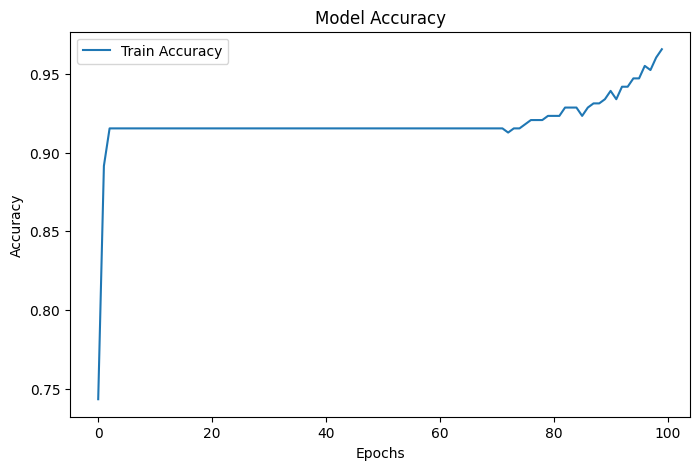

In [15]:
plt.figure(figsize=(8, 5))

# Accuracy Plot
plt.plot(mode_T.history['accuracy'], label='Train Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.show()

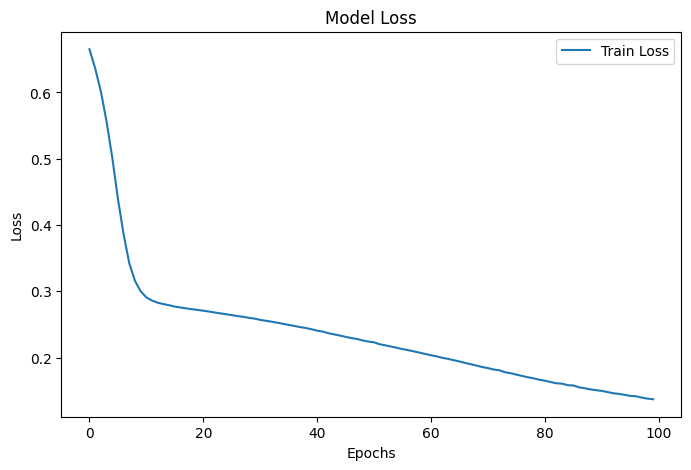

In [16]:
# Loss Plot
plt.figure(figsize=(8, 5))
plt.plot(mode_T.history['loss'], label='Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.show()

In [17]:
y_pred = ann.predict(X_test)
y_pred = (y_pred > 0.5)

cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
[[  2  12]
 [  0 148]]


0.9259259259259259